## Importando dados

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/content/dados_tratados.csv')

## Remoção de Colunas Irrelevantes

In [4]:
df = df.drop('customerID', axis=1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Evasao                         7267 non-null   int64  
 1   cliente.Genero                 7267 non-null   object 
 2   cliente.CidadaoIdoso           7267 non-null   int64  
 3   cliente.Parceiro               7267 non-null   int64  
 4   cliente.Dependentes            7267 non-null   int64  
 5   cliente.MesesContrato          7267 non-null   int64  
 6   telefone.ServicoTelefone       7267 non-null   int64  
 7   telefone.VariasLinhas          7267 non-null   int64  
 8   internet.ServicoInternet       7267 non-null   object 
 9   internet.SegurancaOnline       7267 non-null   int64  
 10  internet.OnlineBackup          7267 non-null   int64  
 11  internet.ProtecaoDispositivos  7267 non-null   int64  
 12  internet.SuporteTecnico        7267 non-null   i

In [6]:
df.head()

,Evasao,cliente.Genero,cliente.CidadaoIdoso,cliente.Parceiro,cliente.Dependentes,cliente.MesesContrato,telefone.ServicoTelefone,telefone.VariasLinhas,internet.ServicoInternet,internet.SegurancaOnline,...,internet.SuporteTecnico,internet.StreamingTV,internet.StreamingFilmes,conta.Contrato,conta.FaturamentoEletronico,conta.MetodoPagamento,conta.Cobrancas.Mensal,conta.Cobrancas.Total,Contas_Diarias,Quantidades_Servicos
0,0,female,0,1,1,9,1,0,dsl,0,...,1,1,0,one year,1,mailed check,65.6,593.30,2.186667,4
1,0,male,0,0,0,9,1,1,dsl,0,...,0,0,1,month-to-month,0,mailed check,59.9,542.40,1.996667,3
2,1,male,0,0,0,4,1,0,fiber optic,0,...,0,0,0,month-to-month,1,electronic check,73.9,280.85,2.463333,2
3,1,male,1,1,0,13,1,0,fiber optic,0,...,0,1,1,month-to-month,1,electronic check,98.0,1237.85,3.266667,5
4,1,female,1,1,0,3,1,0,fiber optic,0,...,1,1,0,month-to-month,1,mailed check,83.9,267.40,2.796667,3


## Encoding

In [7]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [8]:
one_hot_enc = make_column_transformer((
    OneHotEncoder(drop='if_binary'),
    ['cliente.Genero', 'internet.ServicoInternet', 'conta.Contrato',
                       'conta.MetodoPagamento']),
    remainder='passthrough',
    sparse_threshold=0)

In [9]:
df = one_hot_enc.fit_transform(df)

In [10]:
raw_columns = one_hot_enc.get_feature_names_out()

In [11]:
import re

def clean_column_name(col_name):
    return re.sub(r'.*?__', '', col_name)

In [12]:
column_names = [clean_column_name(col) for col in raw_columns]
column_names

['cliente.Genero_male',
 'internet.ServicoInternet_dsl',
 'internet.ServicoInternet_fiber optic',
 'internet.ServicoInternet_no',
 'conta.Contrato_month-to-month',
 'conta.Contrato_one year',
 'conta.Contrato_two year',
 'conta.MetodoPagamento_bank transfer (automatic)',
 'conta.MetodoPagamento_credit card (automatic)',
 'conta.MetodoPagamento_electronic check',
 'conta.MetodoPagamento_mailed check',
 'Evasao',
 'cliente.CidadaoIdoso',
 'cliente.Parceiro',
 'cliente.Dependentes',
 'cliente.MesesContrato',
 'telefone.ServicoTelefone',
 'telefone.VariasLinhas',
 'internet.SegurancaOnline',
 'internet.OnlineBackup',
 'internet.ProtecaoDispositivos',
 'internet.SuporteTecnico',
 'internet.StreamingTV',
 'internet.StreamingFilmes',
 'conta.FaturamentoEletronico',
 'conta.Cobrancas.Mensal',
 'conta.Cobrancas.Total',
 'Contas_Diarias',
 'Quantidades_Servicos']

In [13]:
df = pd.DataFrame(df, columns=column_names)
df.head()

,cliente.Genero_male,internet.ServicoInternet_dsl,internet.ServicoInternet_fiber optic,internet.ServicoInternet_no,conta.Contrato_month-to-month,conta.Contrato_one year,conta.Contrato_two year,conta.MetodoPagamento_bank transfer (automatic),conta.MetodoPagamento_credit card (automatic),conta.MetodoPagamento_electronic check,...,internet.OnlineBackup,internet.ProtecaoDispositivos,internet.SuporteTecnico,internet.StreamingTV,internet.StreamingFilmes,conta.FaturamentoEletronico,conta.Cobrancas.Mensal,conta.Cobrancas.Total,Contas_Diarias,Quantidades_Servicos
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,65.6,593.30,2.186667,4.0
1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,59.9,542.40,1.996667,3.0
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,73.9,280.85,2.463333,2.0
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,98.0,1237.85,3.266667,5.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,83.9,267.40,2.796667,3.0


In [14]:
df.columns

Index(['cliente.Genero_male', 'internet.ServicoInternet_dsl',
       'internet.ServicoInternet_fiber optic', 'internet.ServicoInternet_no',
       'conta.Contrato_month-to-month', 'conta.Contrato_one year',
       'conta.Contrato_two year',
       'conta.MetodoPagamento_bank transfer (automatic)',
       'conta.MetodoPagamento_credit card (automatic)',
       'conta.MetodoPagamento_electronic check',
       'conta.MetodoPagamento_mailed check', 'Evasao', 'cliente.CidadaoIdoso',
       'cliente.Parceiro', 'cliente.Dependentes', 'cliente.MesesContrato',
       'telefone.ServicoTelefone', 'telefone.VariasLinhas',
       'internet.SegurancaOnline', 'internet.OnlineBackup',
       'internet.ProtecaoDispositivos', 'internet.SuporteTecnico',
       'internet.StreamingTV', 'internet.StreamingFilmes',
       'conta.FaturamentoEletronico', 'conta.Cobrancas.Mensal',
       'conta.Cobrancas.Total', 'Contas_Diarias', 'Quantidades_Servicos'],
      dtype='object')

## Verificação da Proporção de Evasão

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df['Evasao'].value_counts()

,count
Evasao,
0.0,5398
1.0,1869


## Correlação e seleção das variáveis

In [17]:
df.corr()['Evasao']

,Evasao
cliente.Genero_male,-0.009555
internet.ServicoInternet_dsl,-0.120020
internet.ServicoInternet_fiber optic,0.300949
internet.ServicoInternet_no,-0.224051
conta.Contrato_month-to-month,0.395584
conta.Contrato_one year,-0.173958
conta.Contrato_two year,-0.295138
conta.MetodoPagamento_bank transfer (automatic),-0.114767
conta.MetodoPagamento_credit card (automatic),-0.131085
conta.MetodoPagamento_electronic check,0.294626


In [18]:
import plotly.express as px

fig = px.box(df, x='cliente.MesesContrato', color='Evasao')
fig.show()

In [19]:
fig = px.box(df, x='conta.Cobrancas.Total', color='Evasao')
fig.show()

## Separação dos dados

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
y = df['Evasao']
X = df.drop('Evasao', axis=1)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=5)

## Modelo base

In [23]:
from sklearn.dummy import DummyClassifier

In [24]:
model_dummy = DummyClassifier()

In [25]:
model_dummy.fit(X_train, y_train)

DummyClassifier()

In [26]:
model_dummy.score(X_train, y_train)

0.7428234368855682

In [27]:
model_dummy.score(X_test, y_test)

0.7427785419532325

## Normalização

In [28]:
from sklearn.preprocessing import MinMaxScaler

In [29]:
normalizacao = MinMaxScaler()

In [30]:
X_train_normalizado = normalizacao.fit_transform(X_train)

In [31]:
pd.DataFrame(X_train_normalizado)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.426295,0.400556,0.426295,0.500
1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.360558,0.182929,0.360558,0.375
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.352092,0.372726,0.352092,0.500
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.531873,0.008250,0.531873,0.125
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.930279,0.914638,0.930279,0.875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5081,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,1.0,1.0,1.0,0.829183,0.104418,0.829183,0.625
5082,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.070717,0.000000,0.070717,0.250
5083,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.223606,0.051734,0.223606,0.375
5084,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.372012,0.232182,0.372012,0.375


## KNN

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [33]:
model_knn = KNeighborsClassifier()

In [34]:
model_knn.fit(X_train_normalizado, y_train)

KNeighborsClassifier()

In [35]:
X_test_normalizado = normalizacao.transform(X_test)

In [36]:
model_knn.score(X_test_normalizado, y_test)

0.761118752865658

## Random forest

In [37]:
from sklearn.tree import DecisionTreeClassifier

In [38]:
model_tree = DecisionTreeClassifier(max_depth=5, random_state=5)

In [39]:
model_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=5)

In [40]:
model_tree.score(X_train, y_train)

0.8051513959889894

In [41]:
model_tree.score(X_test, y_test)

0.7753324163227877

## Escolhendo e salvando o melhor modelo

In [42]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

In [43]:
print(f"Acurácia Dummy: {model_dummy.score(X_test, y_test)}")
print(f"Acurácia KNN: {model_knn.score(X_test_normalizado, y_test)}")
print(f"Acurácia Árvore de decisão: {model_tree.score(X_test, y_test)}")

Acurácia Dummy: 0.7427785419532325
Acurácia KNN: 0.761118752865658
Acurácia Árvore de decisão: 0.7753324163227877


In [44]:
y_previsto = model_tree.predict(X_test)

In [45]:
print(f"Acurácia (Árvore de decisão): {accuracy_score(y_previsto, y_test)}")
print(f"Precisão (Árvore de decisão): {precision_score(y_previsto, y_test)}")
print(f"Recall (Árvore de decisão): {recall_score(y_previsto, y_test)}")
print(f"F1-Score (Árvore de decisão): {f1_score(y_previsto, y_test)}")

Acurácia (Árvore de decisão): 0.7753324163227877
Precisão (Árvore de decisão): 0.3672014260249554
Recall (Árvore de decisão): 0.6041055718475073
F1-Score (Árvore de decisão): 0.4567627494456763


In [46]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [47]:
matriz_confusao = confusion_matrix(y_test, y_previsto)

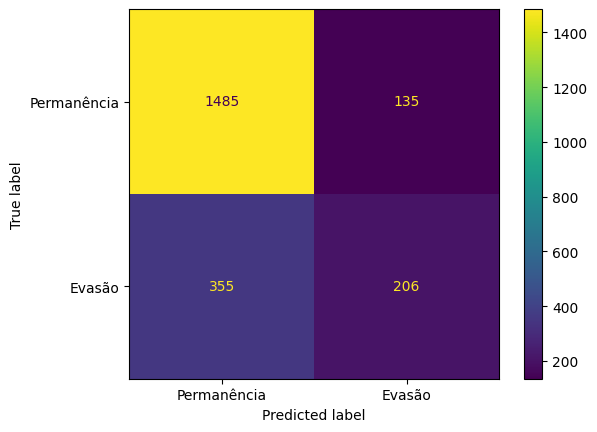

In [48]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix= matriz_confusao,
                                      display_labels=['Permanência','Evasão'])

visualizacao.plot();

## Interpretação e Conclusões

In [56]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Escalar os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
baseline_acc = accuracy_score(y_test, knn.predict(X_test_scaled))

# Avaliando importância por permutação
importances = {}
for i, col in enumerate(X.columns):
    X_test_shuffled = X_test_scaled.copy()
    np.random.shuffle(X_test_shuffled[:, i])  # embaralha a coluna
    acc = accuracy_score(y_test, knn.predict(X_test_shuffled))
    importances[col] = baseline_acc - acc

# Ordenar por maior impacto
importances = dict(sorted(importances.items(), key=lambda x: x[1], reverse=True))

for col, importance in importances.items():
  print(f"{col}: {importance}")

conta.Cobrancas.Total: 0.015130674002751032
internet.StreamingFilmes: 0.011004126547455195
conta.MetodoPagamento_credit card (automatic): 0.008253094910591452
telefone.VariasLinhas: 0.006877579092159469
cliente.MesesContrato: 0.006419073819348919
internet.StreamingTV: 0.006419073819348919
internet.OnlineBackup: 0.0059605685465382585
conta.Contrato_month-to-month: 0.004585052728106276
cliente.CidadaoIdoso: 0.004585052728106276
internet.ServicoInternet_fiber optic: 0.004126547455295726
Quantidades_Servicos: 0.004126547455295726
cliente.Genero_male: 0.003668042182485065
internet.ServicoInternet_dsl: 0.003668042182485065
cliente.Dependentes: 0.003668042182485065
internet.SegurancaOnline: 0.003668042182485065
conta.MetodoPagamento_electronic check: 0.0027510316368637433
cliente.Parceiro: 0.0027510316368637433
conta.Cobrancas.Mensal: 0.0018340210912425325
conta.MetodoPagamento_mailed check: 0.0013755158184318717
internet.SuporteTecnico: 0.0013755158184318717
internet.ServicoInternet_no: 0.00

# Relatório de Análise de Evasão de Clientes

## Introdução

A evasão de clientes (churn) é um desafio crítico para empresas de telecomunicações, impactando diretamente a receita e a sustentabilidade do negócio. Compreender os fatores que levam os clientes a cancelar serviços permite desenvolver estratégias de retenção mais eficazes, melhorar a experiência do cliente e reduzir perdas financeiras.

Neste relatório, apresentamos uma análise detalhada dos dados de clientes da TelecomX, utilizando técnicas de aprendizado de máquina para identificar os principais fatores de evasão e propor estratégias de retenção baseadas em evidências.

## Objetivo

Identificar os principais fatores que influenciam a evasão de clientes e propor estratégias de retenção com base em modelos de aprendizado de máquina aplicados aos dados tratados.

## Análise Exploratória

A variável-alvo Evasão está desbalanceada.

Correlação e gráficos de boxplot indicam que:

* **Tempo de contrato (meses de permanência) influencia fortemente a evasão:** clientes com contratos curtos tendem a sair mais rápido.

* **Valor total de cobranças também tem relação:** clientes com custos mais altos apresentam maior evasão.

* **Tipo de contrato e forma de pagamento são determinantes:** pagamentos mensais e boleto apresentam mais evasão em comparação a contratos anuais e débito automático.

## Recomendações de Retenção

Com base nos insights, recomenda-se:

1. **Incentivar Contratos de Longo Prazo:** Oferecer descontos ou benefícios adicionais para migração de contratos mensais para anuais ou trimestrais.

2. **Reduzir Percepção de Custo Elevado:** Criar pacotes customizados que atendam diferentes perfis de consumo e implementar programas de fidelidade para clientes de longa data.

3. **Facilitar Métodos de Pagamento:** Estimular o uso de débito automático ou cartão de crédito, oferecendo vantagens em relação ao boleto.

4. **Foco em Clientes de Alto Risco:** Monitorar clientes novos e com cobranças altas, realizando campanhas de retenção personalizadas antes do cancelamento.

5. **Melhorar Qualidade do Serviço de Internet:** Investir em suporte técnico, planos flexíveis e canais de atendimento rápido para problemas de conectividade.

## Conclusão

O modelo de Árvore de Decisão apresentou o melhor equilíbrio entre acurácia e interpretabilidade, confirmando que os principais fatores de evasão são tempo de contrato, valor de cobranças, tipo de contrato, método de pagamento e serviço de internet.

Apesar do bom desempenho geral, a matriz de confusão revelou que algumas evasões reais não estão sendo identificadas satisfatoriamente, indicando a necessidade de ajustes futuros no modelo ou estratégias complementares de monitoramento.

Estratégias de retenção devem priorizar contratos de longo prazo, formas de pagamento automáticas e personalização da experiência do cliente, enquanto melhorias futuras no modelo podem aumentar ainda mais a precisão na detecção de clientes em risco de evasão.